In [2]:
#Let’s import the libraries we’ll be using.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict
from io import StringIO

%matplotlib inline
import seaborn as sns
sns.set_style('white')
sns.set_style('ticks')
sns.set_context('notebook')
from scipy.spatial.distance import squareform
import h5py
import allel
import zarr
import matplotlib.pyplot as plt
from cycler import cycler
import allel
import glob
import os
import pickle
import csv
#import pybedtools
from scipy.special import logit
import warnings

#### Maesot CHromosome 09-14, $4N_er$ per kb 

In [3]:

# Step 1: Read the res.txt file
res1 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom09_ms/res.txt", sep='\s+')
res2 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom10_ms/res.txt", sep='\s+')
res3 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom11_ms/res.txt", sep='\s+')
res4 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom12_ms/res.txt", sep='\s+')
res5 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom13_ms/res.txt", sep='\s+')
res6 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom14_ms/res.txt", sep='\s+')



<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_82136/2813822030.py:2: SyntaxWarning: invalid escape sequence '\s'
  res1 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom09_ms/res.txt", sep='\s+')
/tmp/ipykernel_82136/2813822030.py:3: SyntaxWarning: invalid escape sequence '\s'
  res2 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data

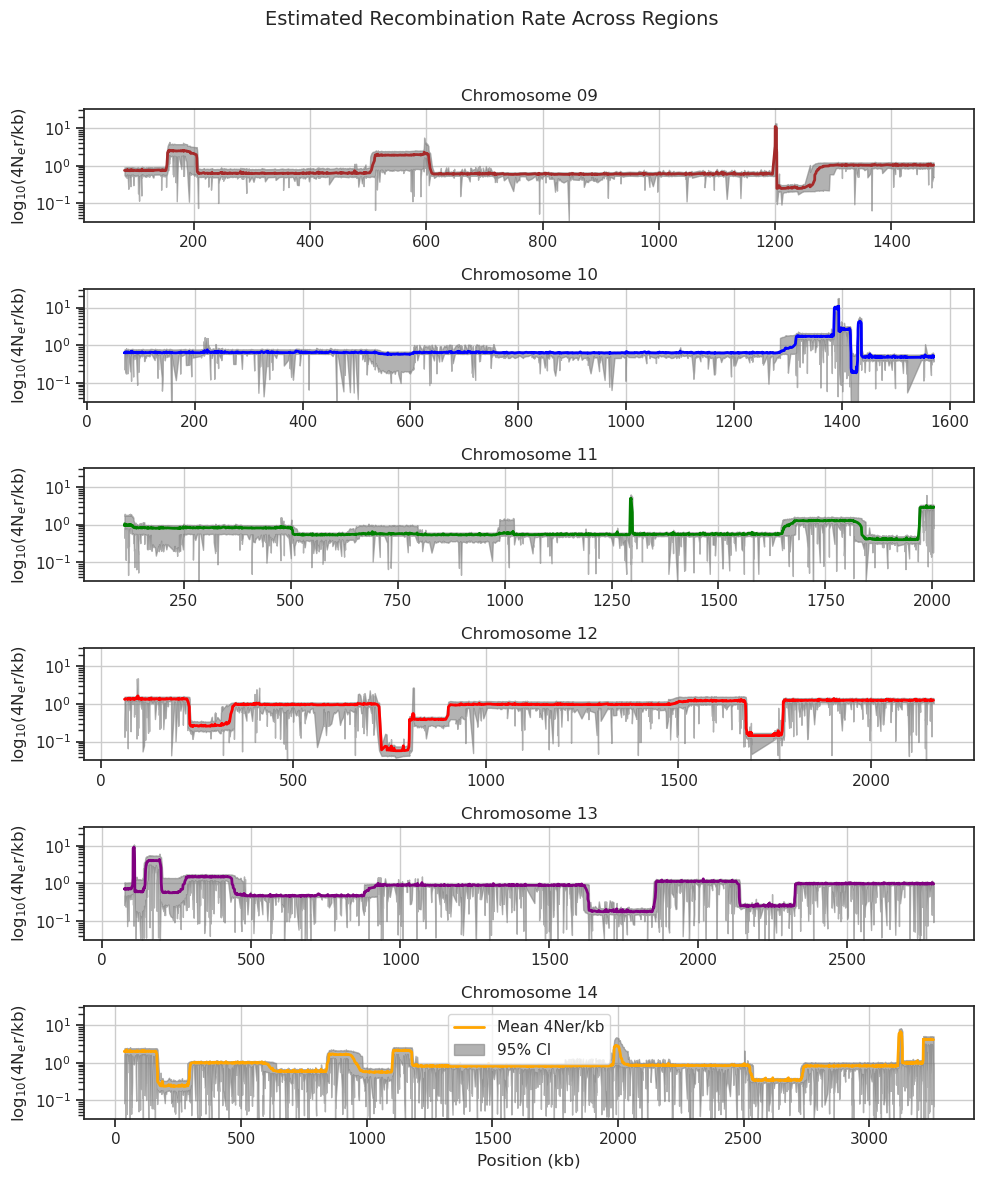

In [4]:
# Remove the summary row (Loci == -1.000)
res1 = res1[res1['Loci'] > 0]
res2 = res2[res2['Loci'] > 0]
res3 = res3[res3['Loci'] > 0]
res4 = res4[res4['Loci'] > 0]
res5 = res5[res5['Loci'] > 0]
res6 = res6[res6['Loci'] > 0]

chrom_names = ["Chromosome 09", "Chromosome 10", "Chromosome 11", "Chromosome 12",
               "Chromosome 13", "Chromosome 14"]
dfs = [res1, res2, res3, res4, res5, res6]

colors = ["brown","blue", "green", "red", "purple", "orange"]

fig, axes = plt.subplots(6, 1, figsize=(10, 12))

for ax, df, name, color in zip(axes, dfs, chrom_names, colors):
    ax.plot(df['Loci'], df['Mean_rho'], label='Mean 4Ner/kb',
            color=color, linewidth=2)
    ax.fill_between(df['Loci'], df['L95'], df['U95'],
                    color='gray', alpha=0.6, label='95% CI')
    ax.set_ylabel(r'log$_{10}$(4N$_e$r/kb)')
    ax.set_title(name)
    ax.set_ylim(10**-1.5, 10**1.5)
    ax.set_yscale('log')
    ax.grid(True)

axes[-1].set_xlabel("Position (kb)")
axes[-1].legend()

fig.suptitle("Estimated Recombination Rate Across Regions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#### Maesot: with mask

In [5]:

warnings.filterwarnings('ignore')

# Step 1: Read the res.txt file
res1 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom09/res.txt", sep='\s+')
res2 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom10/res.txt", sep='\s+')
res3 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom11/res.txt", sep='\s+')
res4 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom12/res.txt", sep='\s+')
res5 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom13/res.txt", sep='\s+')
res6= pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom14/res.txt", sep='\s+')



<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_82136/3130723230.py:4: SyntaxWarning: invalid escape sequence '\s'
  res1 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom09/res.txt", sep='\s+')
/tmp/ipykernel_82136/3130723230.py:5: SyntaxWarning: invalid escape sequence '\s'
  res2 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_re

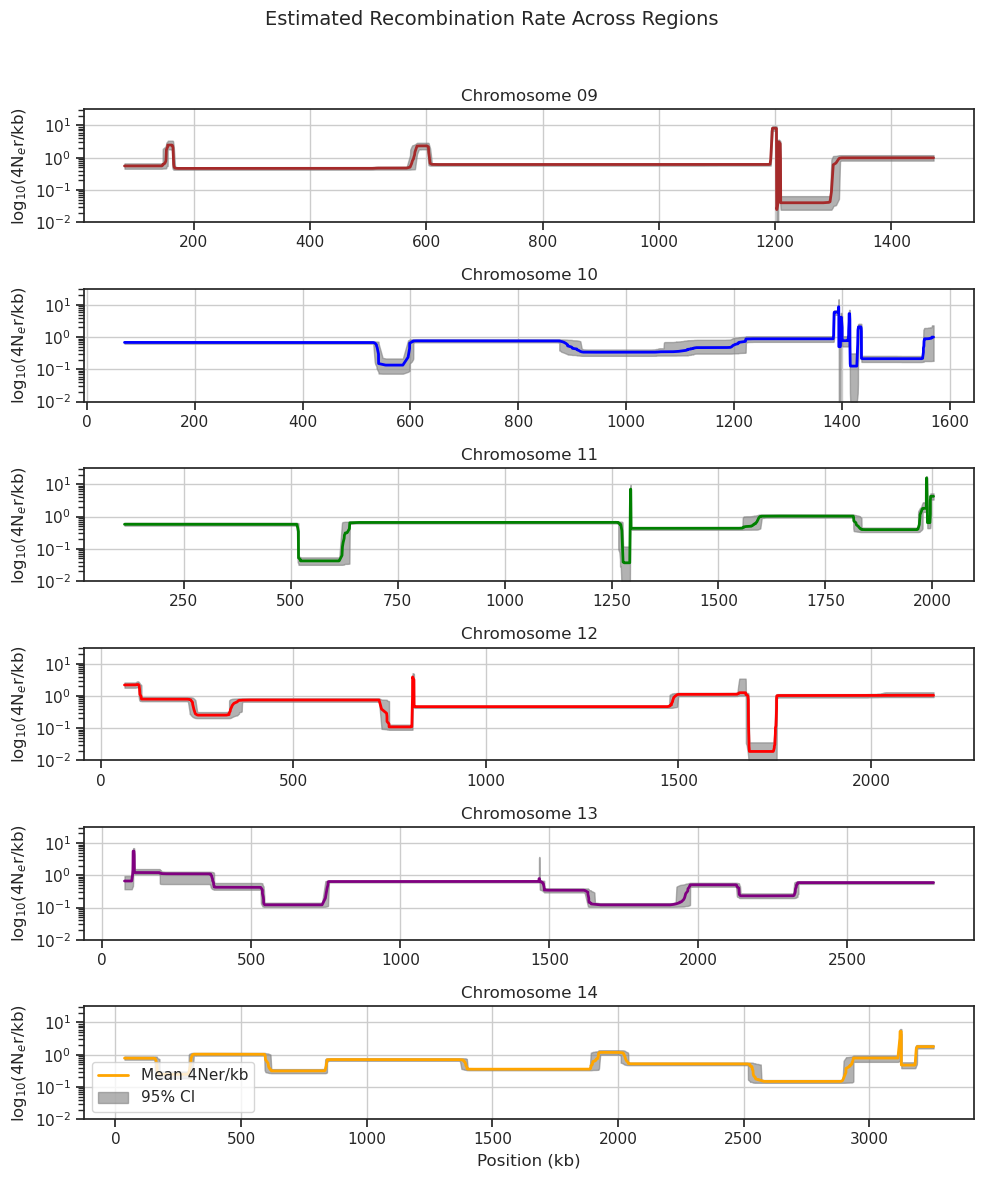

In [6]:
# Remove the summary row (Loci == -1.000)
res1 = res1[res1['Loci'] > 0]
res2 = res2[res2['Loci'] > 0]
res3 = res3[res3['Loci'] > 0]
res4 = res4[res4['Loci'] > 0]
res5 = res5[res5['Loci'] > 0]
res6 = res6[res6['Loci'] > 0]

chrom_names = ["Chromosome 09", "Chromosome 10", "Chromosome 11", "Chromosome 12",
               "Chromosome 13", "Chromosome 14"]
dfs = [res1, res2, res3, res4, res5, res6]

colors = ["brown","blue", "green", "red", "purple", "orange"]

fig, axes = plt.subplots(6, 1, figsize=(10, 12))

for ax, df, name, color in zip(axes, dfs, chrom_names, colors):
    ax.plot(df['Loci'], df['Mean_rho'], label='Mean 4Ner/kb',
            color=color, linewidth=2)
    ax.fill_between(df['Loci'], df['L95'], df['U95'],
                    color='gray', alpha=0.6, label='95% CI')
    ax.set_ylabel(r'log$_{10}$(4N$_e$r/kb)')
    ax.set_title(name)
    ax.set_ylim(10**-2, 10**1.5)
    ax.set_yscale('log')
    ax.grid(True)

axes[-1].set_xlabel("Position (kb)")
axes[-1].legend()

fig.suptitle("Estimated Recombination Rate Across Regions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##### Watterson Theta

In [7]:
zarr_full = '/home/usriniva/Desktop/masters/zarrs/Pf3D7_dep10_90x_AB0.9_qcpass_White_Allchr_combined_final_filtered_haploid.zarr'
callset_full = zarr.open_group(zarr_full, mode='r')

# Load the right table
samples_p = '/home/usriniva/Desktop/masters/plasmodium/VCFs/2_Samplemd_files/Final_Dataset_bydapcclusters_remoutliers/Allchr_Whitefullfilt_Newdapc_bycluster_md.txt'
samples_right = pd.read_csv(samples_p, sep='\t')
print('No of Individuals (right table):', len(samples_right))

# Add 'subpops' information based on 'assgn_clus'
samples_right['subpops'] = 'NA'  # Default value for unmatched samples
samples_right.loc[samples_right['assgn_clus'] == 1, 'subpops'] = 'MaeSot_Thailand'
samples_right.loc[samples_right['assgn_clus'] == 6, 'subpops'] = 'PurPai_Cambodia'
samples_right.loc[samples_right['assgn_clus'] == 4, 'subpops'] = 'BinhPhuoc_Long_Vietnam'

# Load the left table
samples_o_p = '/home/usriniva/Desktop/masters/plasmodium/VCFs/2_Samplemd_files/Total_dataset_TRACwhite2011/White_1052_ctv_471inds_depthfilt_samplemd.txt'
samples_left = pd.read_csv(samples_o_p, sep='\t')
print('No of Individuals (left table):', len(samples_left))

# Merge the tables using a left join: match 'Sample' from the left table with 'Individuals' from the right
merged = samples_left.merge(samples_right[['Individual', 'subpops']], how='left', left_on='Sample', right_on='Individual')

# Verify the data type of 'assgn_clus'
print(f"Data type of 'subpops': {merged['subpops'].dtype}")

# Check if 'assgn_clus' contains only the values 1, 4, 6
print(merged['subpops'].value_counts())
# Define subpopulations based on 'subpops' column in the merged DataFrame
subpops = {
    'all': list(range(len(merged))),  # All individuals in the merged dataset
    'MaeSot_Thailand': merged[merged['subpops'] == "MaeSot_Thailand"].index.tolist(),
    'PurPai_Cambodia': merged[merged['subpops'] == "PurPai_Cambodia"].index.tolist(),
    'BinhPhuoc_Long_Vietnam': merged[merged['subpops'] == "BinhPhuoc_Long_Vietnam"].index.tolist()
}

gt_zarr = callset_full['All_chr/calldata/GT']
gt_zarr.info
gt = allel.HaplotypeArray(callset_full['All_chr/calldata/GT'][:,:,0])
gt
genotypes_full = allel.HaplotypeChunkedArray(gt)
print(len(genotypes_full))

variants_full = allel.VariantChunkedTable(callset_full['All_chr/variants'], 
                                     names=['POS', 'CHROM', 'numalt', 'REF', 'ALT', 'DP', 'MQ', 'QD','ANN_Annotation'])
gt_full = allel.HaplotypeArray(callset_full['All_chr/calldata/GT'][:,:,0])

genotypes_full = allel.HaplotypeChunkedArray(gt_full)


No of Individuals (right table): 270
No of Individuals (left table): 448
Data type of 'subpops': str
subpops
BinhPhuoc_Long_Vietnam    156
MaeSot_Thailand            89
PurPai_Cambodia            25
Name: count, dtype: int64
480058


In [8]:
chrom_uniq = np.unique(variants_full['CHROM'])
chrom_variants = {}
chrom_pos = {}
chrom_gt = {}
chrom_range_bp_list = []
theta_hat_w_Maesot = {}
theta_hat_w_Binh_Viet ={}

for chrom in chrom_uniq[8:14]:
    
    # Load genotypes and calculate allele counts
    mask_chrom = variants_full['CHROM'] == chrom
    # Use compress to subset the variants for the current chromosome
    chrom_variants[chrom] = variants_full.compress(mask_chrom)
    # Extract the positions for the current chromosome from the filtered variants
    chrom_pos[chrom] = np.unique(chrom_variants[chrom]['POS'])
    # Subset genotypes for the current chromosome
    chrom_gt[chrom] = genotypes_full.compress(mask_chrom)
    
    ac_subpops = chrom_gt[chrom].count_alleles_subpops(subpops, max_allele=2)
    
    theta_hat_w_Maesot[chrom] = allel.watterson_theta(chrom_pos[chrom], ac_subpops['MaeSot_Thailand'])
    
    theta_hat_w_Binh_Viet[chrom] = allel.watterson_theta(chrom_pos[chrom], ac_subpops['BinhPhuoc_Long_Vietnam'])


##### Calculating $\frac{\rho}{\theta}$ for Maesot

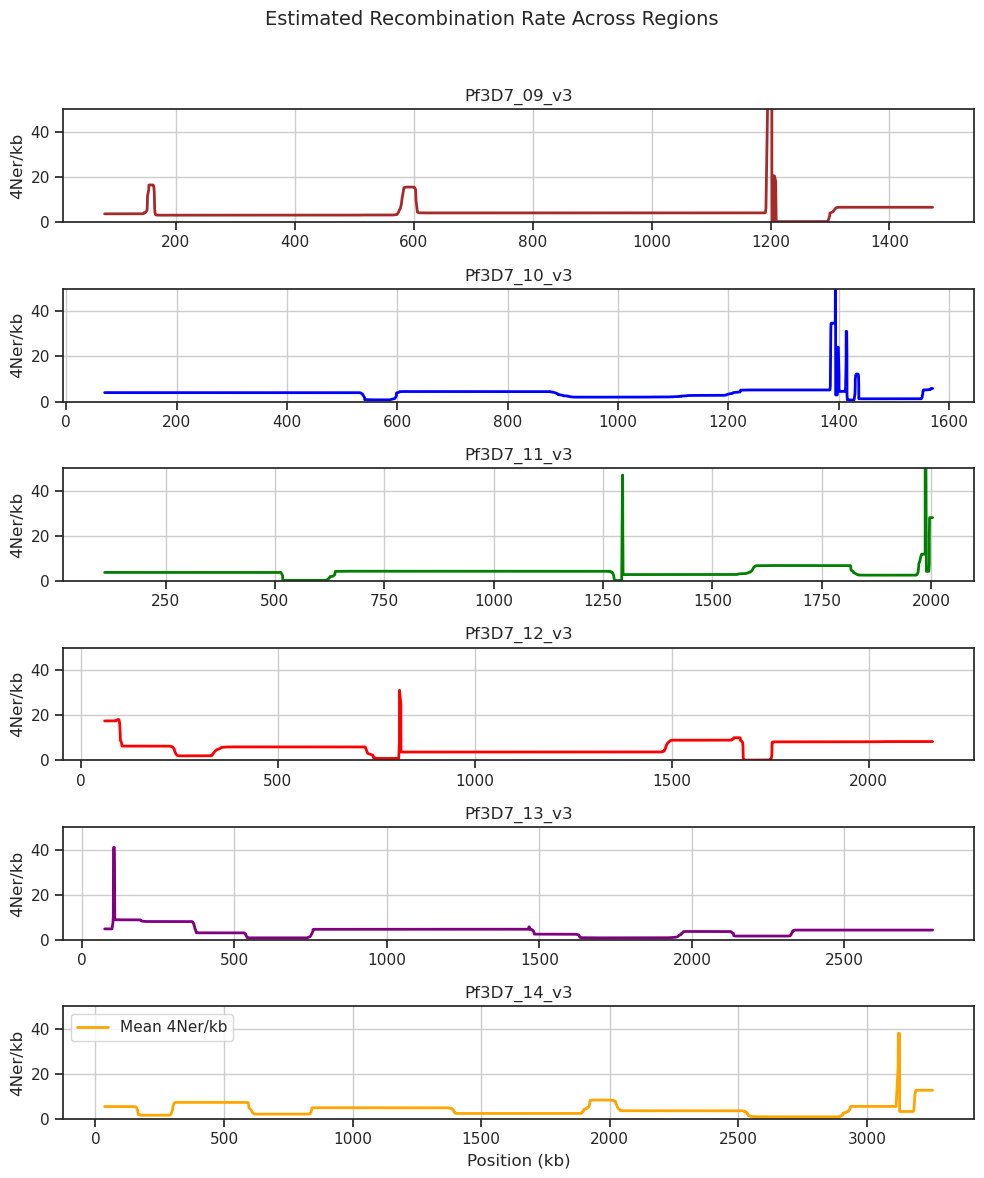

In [9]:

# Step 1: Read the res.txt file
res1 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom09/res.txt", sep='\s+')
res2 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom10/res.txt", sep='\s+')
res3 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom11/res.txt", sep='\s+')
res4 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom12/res.txt", sep='\s+')
res5 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom13/res.txt", sep='\s+')
res6= pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Ms_chrom14/res.txt", sep='\s+')

res1 = res1[res1['Loci'] > 0]
res2 = res2[res2['Loci'] > 0]
res3 = res3[res3['Loci'] > 0]
res4 = res4[res4['Loci'] > 0]
res5 = res5[res5['Loci'] > 0]
res6 = res6[res6['Loci'] > 0]

chrom_names = ["Chromosome 09", "Chromosome 10", "Chromosome 11", "Chromosome 12",
               "Chromosome 13", "Chromosome 14"]
dfs = [res1, res2, res3, res4, res5, res6]

colors = ["brown","blue", "green", "red", "purple", "orange"]

fig, axes = plt.subplots(6, 1, figsize=(10, 12))

for ax, df, (name, theta_w), color in zip(axes, dfs, theta_hat_w_Maesot.items(), colors):
    theta_w_kb = theta_w*1000
    ax.plot(df['Loci'], df['Mean_rho']/ theta_w_kb, label='Mean 4Ner/kb',
            color=color, linewidth=2)
    ax.set_ylabel("4Ner/kb")
    ax.set_title(name)
    ax.set_ylim(0,50)
    #ax.set_yscale('log')
    ax.grid(True)
    
axes[-1].set_xlabel("Position (kb)")
axes[-1].legend()

fig.suptitle("Estimated Recombination Rate Across Regions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [10]:
hi_rho_theta = {}
for df, (name, theta_w) in zip(dfs, theta_hat_w_Maesot.items()):
    theta_w_kb = theta_w*1000
    df['rho_theta'] = df['Mean_rho']/ theta_w_kb 
    # Filter high-rho rows
    high_rho_theta_subset = df[df['rho_theta'] > 50].copy()
    hi_rho_theta[name] = high_rho_theta_subset

with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
       
    print(hi_rho_theta['Pf3D7_10_v3'])
 

         Loci  Mean_rho   Median      L95       U95  rho_theta
843  1393.947   8.65015  6.44797  5.69661  14.92084  50.366438
844  1393.970   8.74435  6.46898  5.74295  14.92084  50.914927
845  1394.020   8.74435  6.46898  5.74295  14.92084  50.914927
846  1394.023   8.74435  6.46898  5.74295  14.92084  50.914927
847  1394.030   8.74435  6.46898  5.74295  14.92084  50.914927
848  1394.128   8.74435  6.46898  5.74295  14.92084  50.914927
849  1394.135   8.74435  6.46898  5.74295  14.92084  50.914927
850  1394.389   8.74435  6.46898  5.74295  14.92084  50.914927


### BinhPhuoc Vietnam

#### Without Mask

In [12]:

# Step 1: Read the res.txt file
res1 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom09_bv/res.txt", sep='\s+')
res2 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom10_bv/res.txt", sep='\s+')
res3 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom11_bv/res.txt", sep='\s+')
res4 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom12_bv/res.txt", sep='\s+')
res5 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom13_bv/res.txt", sep='\s+')
res6 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom14_bv/res.txt", sep='\s+')


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_141088/159660454.py:2: SyntaxWarning: invalid escape sequence '\s'
  res1 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom09_bv/res.txt", sep='\s+')
/tmp/ipykernel_141088/159660454.py:3: SyntaxWarning: invalid escape sequence '\s'
  res2 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data

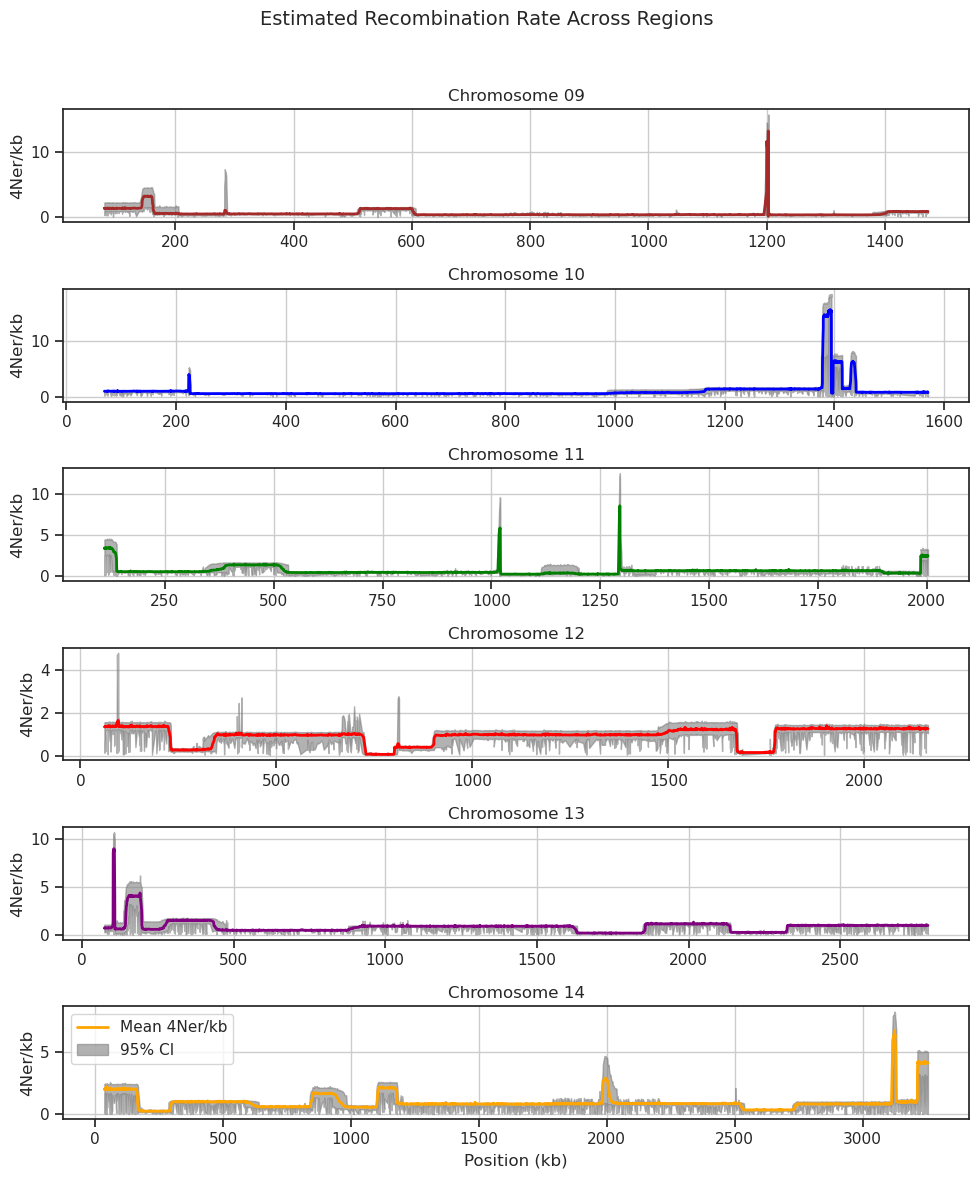

In [13]:
# Remove the summary row (Loci == -1.000)
res1 = res1[res1['Loci'] > 0]
res2 = res2[res2['Loci'] > 0]
res3 = res3[res3['Loci'] > 0]
res4 = res4[res4['Loci'] > 0]
res5 = res5[res5['Loci'] > 0]
res6 = res6[res6['Loci'] > 0]

chrom_names = ["Chromosome 09", "Chromosome 10", "Chromosome 11", "Chromosome 12",
               "Chromosome 13", "Chromosome 14"]
dfs = [res1, res2, res3, res4, res5, res6]

colors = ["brown","blue", "green", "red", "purple", "orange"]

fig, axes = plt.subplots(6, 1, figsize=(10, 12))

for ax, df, name, color in zip(axes, dfs, chrom_names, colors):
    ax.plot(df['Loci'], df['Mean_rho'], label='Mean 4Ner/kb',
            color=color, linewidth=2)
    ax.fill_between(df['Loci'], df['L95'], df['U95'],
                    color='gray', alpha=0.6, label='95% CI')
    ax.set_ylabel("4Ner/kb")
    ax.set_title(name)
    ax.grid(True)

axes[-1].set_xlabel("Position (kb)")
axes[-1].legend()

fig.suptitle("Estimated Recombination Rate Across Regions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_141088/3927305003.py:2: SyntaxWarning: invalid escape sequence '\s'
  res1 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom09_bv/res.txt", sep='\s+')
/tmp/ipykernel_141088/3927305003.py:3: SyntaxWarning: invalid escape sequence '\s'
  res2 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_da

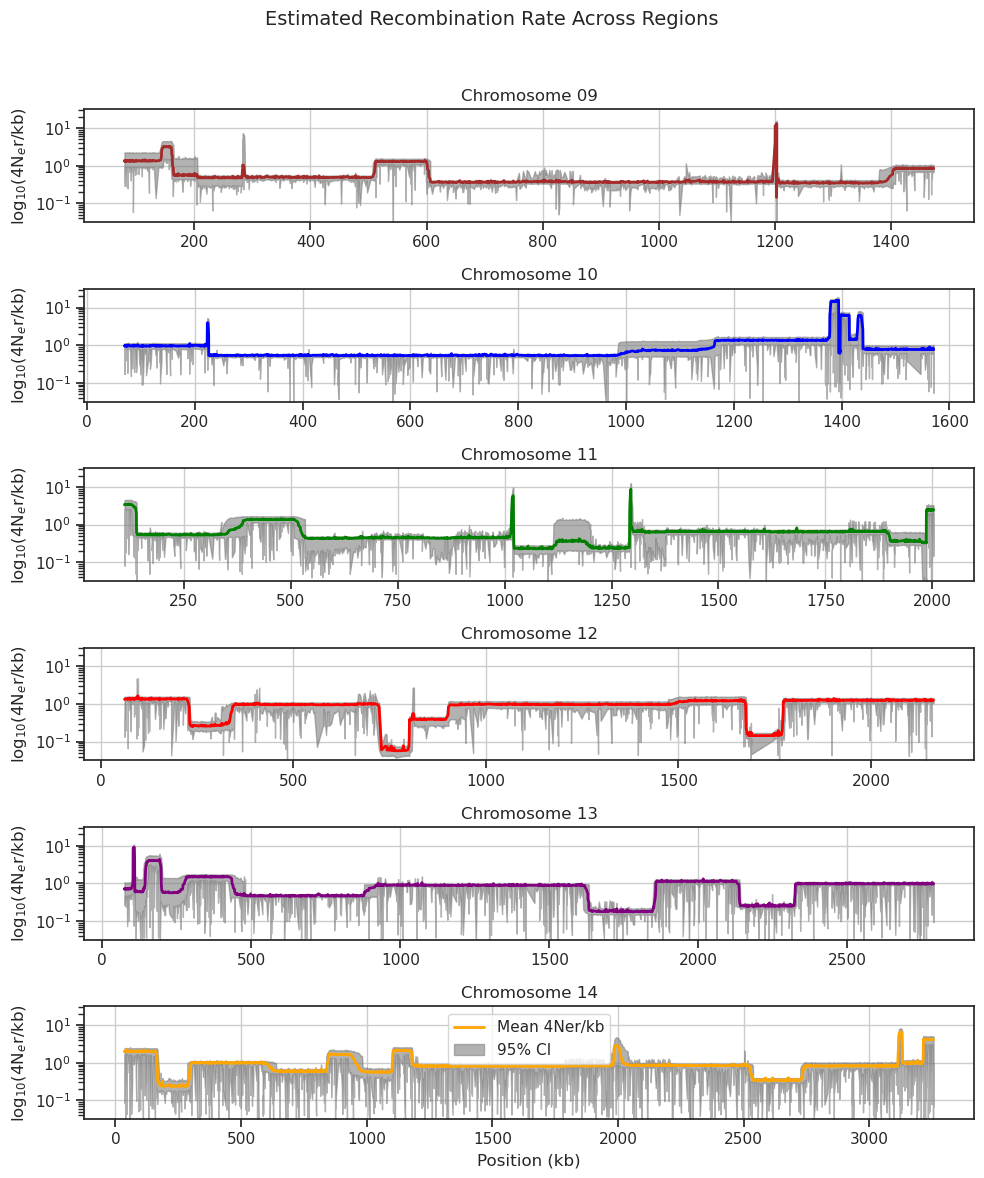

In [11]:

# Step 1: Read the res.txt file
res1 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom09_bv/res.txt", sep='\s+')
res2 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom10_bv/res.txt", sep='\s+')
res3 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom11_bv/res.txt", sep='\s+')
res4 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom12_bv/res.txt", sep='\s+')
res5 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom13_bv/res.txt", sep='\s+')
res6 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_womask/interval_chrom14_bv/res.txt", sep='\s+')


# Remove the summary row (Loci == -1.000)
res1 = res1[res1['Loci'] > 0]
res2 = res2[res2['Loci'] > 0]
res3 = res3[res3['Loci'] > 0]
res4 = res4[res4['Loci'] > 0]
res5 = res5[res5['Loci'] > 0]
res6 = res6[res6['Loci'] > 0]

chrom_names = ["Chromosome 09", "Chromosome 10", "Chromosome 11", "Chromosome 12",
               "Chromosome 13", "Chromosome 14"]
dfs = [res1, res2, res3, res4, res5, res6]

colors = ["brown","blue", "green", "red", "purple", "orange"]

fig, axes = plt.subplots(6, 1, figsize=(10, 12))

for ax, df, name, color in zip(axes, dfs, chrom_names, colors):
    ax.plot(df['Loci'], df['Mean_rho'], label='Mean 4Ner/kb',
            color=color, linewidth=2)
    ax.fill_between(df['Loci'], df['L95'], df['U95'],
                    color='gray', alpha=0.6, label='95% CI')
    ax.set_ylabel(r'log$_{10}$(4N$_e$r/kb)')
    ax.set_title(name)
    ax.set_ylim(10**-1.5, 10**1.5)
    ax.set_yscale('log')
    ax.grid(True)

axes[-1].set_xlabel("Position (kb)")
axes[-1].legend()

fig.suptitle("Estimated Recombination Rate Across Regions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##### With Mask

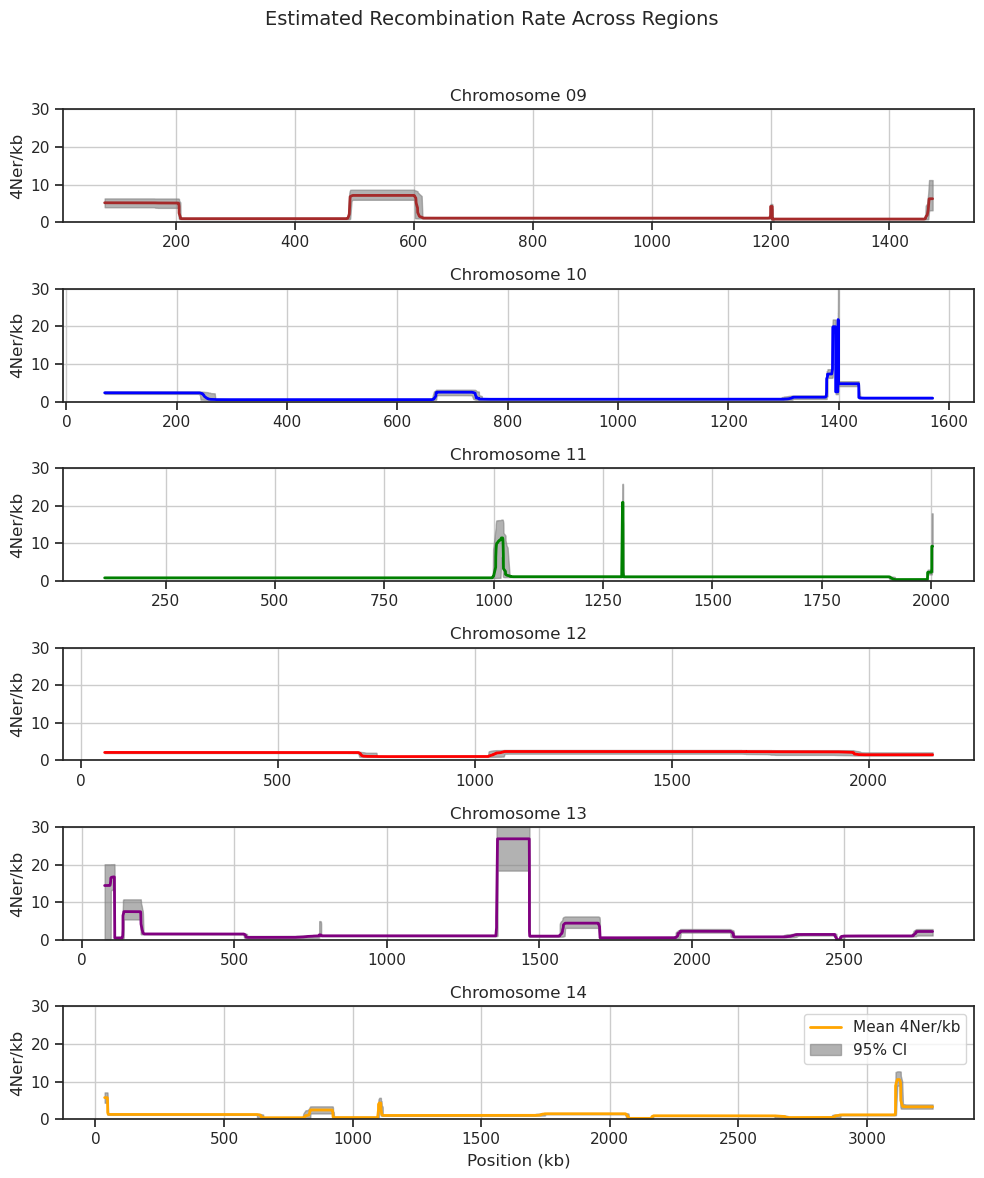

In [40]:
# Step 1: Read the res.txt file
res1 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom09/res.txt", sep='\s+')
res2 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom10/res.txt", sep='\s+')
res3 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom11/res.txt", sep='\s+')
res4 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom12/res.txt", sep='\s+')
res5 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom13/res.txt", sep='\s+')
res6 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom14/res.txt", sep='\s+')

# Remove the summary row (Loci == -1.000)
res1 = res1[res1['Loci'] > 0]
res2 = res2[res2['Loci'] > 0]
res3 = res3[res3['Loci'] > 0]
res4 = res4[res4['Loci'] > 0]
res5 = res5[res5['Loci'] > 0]
res6 = res6[res6['Loci'] > 0]

chrom_names = ["Chromosome 09", "Chromosome 10", "Chromosome 11", "Chromosome 12",
               "Chromosome 13", "Chromosome 14"]
dfs = [res1, res2, res3, res4, res5, res6]

colors = ["brown","blue", "green", "red", "purple", "orange"]

fig, axes = plt.subplots(6, 1, figsize=(10, 12))

for ax, df, name, color in zip(axes, dfs, chrom_names, colors):
    ax.plot(df['Loci'], df['Mean_rho'], label='Mean 4Ner/kb',
            color=color, linewidth=2)
    ax.fill_between(df['Loci'], df['L95'], df['U95'],
                    color='gray', alpha=0.6, label='95% CI')
    ax.set_ylabel("4Ner/kb")
    ax.grid(True)
    ax.set_title(name)
    ax.set_ylim(0,30)
    ax.grid(True)

axes[-1].set_xlabel("Position (kb)")
axes[-1].legend()

fig.suptitle("Estimated Recombination Rate Across Regions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


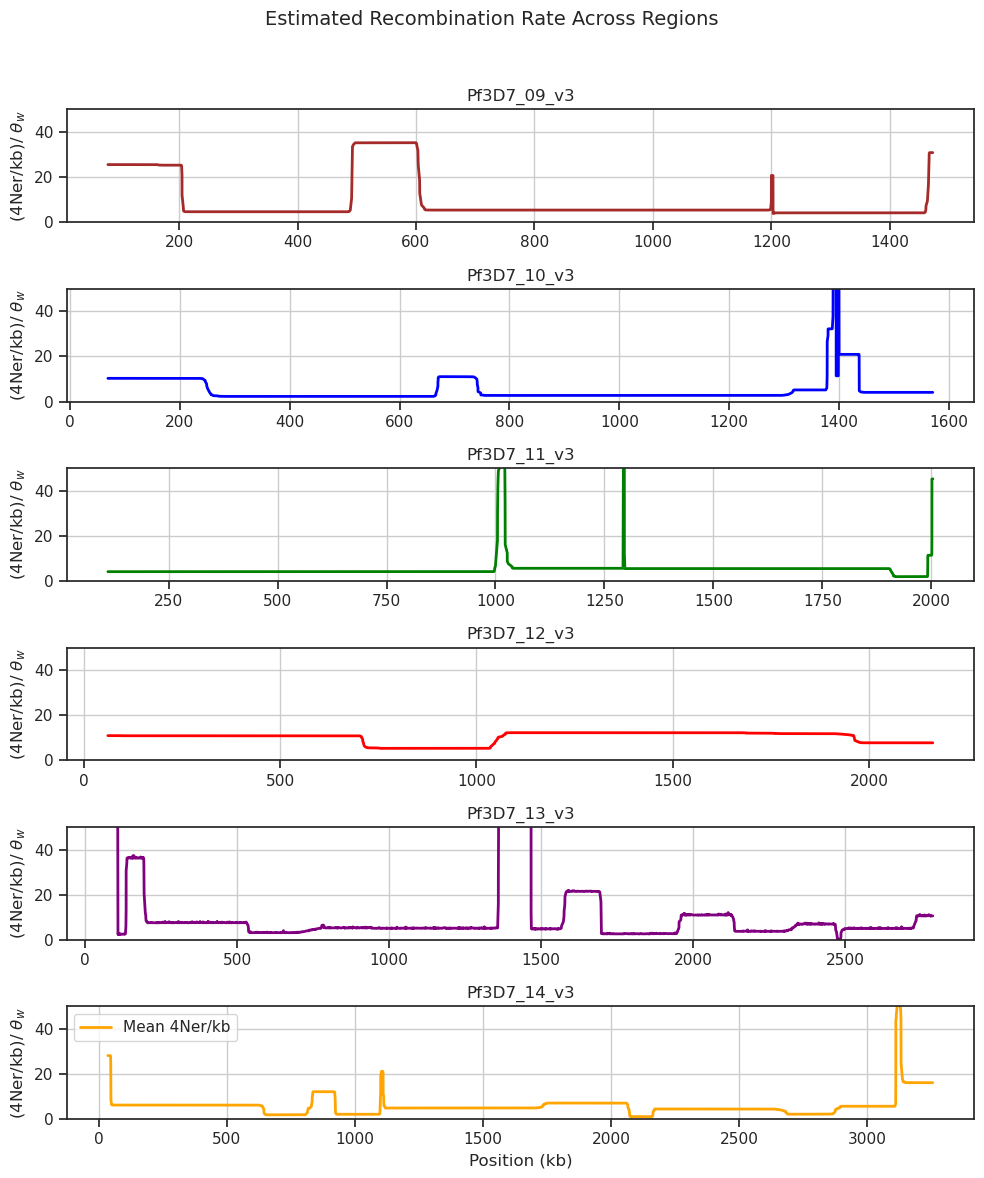

In [68]:
# Step 1: Read the res.txt file
res1 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom09/res.txt", sep='\s+')
res2 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom10/res.txt", sep='\s+')
res3 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom11/res.txt", sep='\s+')
res4 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom12/res.txt", sep='\s+')
res5 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom13/res.txt", sep='\s+')
res6 = pd.read_csv("/home/usriniva/Desktop/masters/Plasmodium_us_scripts/ld_hat_data/LD_hat_results_wmask/Bv_chrom14/res.txt", sep='\s+')


res1 = res1[res1['Loci'] > 0]
res2 = res2[res2['Loci'] > 0]
res3 = res3[res3['Loci'] > 0]
res4 = res4[res4['Loci'] > 0]
res5 = res5[res5['Loci'] > 0]
res6 = res6[res6['Loci'] > 0]

chrom_names = ["Chromosome 09", "Chromosome 10", "Chromosome 11", "Chromosome 12",
               "Chromosome 13", "Chromosome 14"]
dfs = [res1, res2, res3, res4, res5, res6]

colors = ["brown","blue", "green", "red", "purple", "orange"]

fig, axes = plt.subplots(6, 1, figsize=(10, 12))

for ax, df, (name, theta_w), color in zip(axes, dfs, theta_hat_w_Binh_Viet.items(), colors):
    theta_w_kb = theta_w*1000
    ax.plot(df['Loci'], df['Mean_rho']/ theta_w_kb, label='Mean 4Ner/kb',
            color=color, linewidth=2)
    ax.set_ylabel(rf"(4Ner/kb)/ $\theta_w$")
    ax.set_title(name)
    ax.set_ylim(0,50)
    #ax.set_yscale('log')
    ax.grid(True)
    
axes[-1].set_xlabel("Position (kb)")
axes[-1].legend()

fig.suptitle("Estimated Recombination Rate Across Regions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [66]:
hi_rho_theta = {}
for df, (name, theta_w) in zip(dfs, theta_hat_w_Binh_Viet.items()):
    theta_w_kb = theta_w*1000
    df['rho_theta'] = df['Mean_rho']/ theta_w_kb 
    # Filter high-rho rows
    high_rho_theta_subset = df[df['rho_theta'] > 50].copy()
    hi_rho_theta[name] = high_rho_theta_subset
    
 

In [67]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
       
    print(hi_rho_theta['Pf3D7_13_v3'])

          Loci  Mean_rho    Median       L95       U95   rho_theta
1       74.436  11.74137  15.56678   0.10413  19.85968   58.183188
2       74.832  11.74175  15.56678   0.08200  19.85968   58.185071
3       76.245  11.75302  15.56678   0.12280  19.85968   58.240918
4       77.864  11.75003  15.56678   0.10691  19.85968   58.226102
5       78.098  11.74032  15.56678   0.06472  19.85968   58.177985
6       78.110  11.75612  15.56678   0.11184  19.85968   58.256280
7       78.232  11.75433  15.56678   0.11346  19.85968   58.247410
8       80.156  11.75553  15.56678   0.11184  19.85968   58.253356
9       82.052  11.75165  15.56678   0.12280  19.85968   58.234129
10      83.373  11.77641  15.56678   0.11346  19.85968   58.356825
11      83.734  11.74419  15.56678   0.10903  19.85968   58.197162
12      86.201  11.75631  15.56678   0.12280  19.85968   58.257221
13      87.429  11.74151  15.56678   0.06701  19.85968   58.183882
14      87.443  11.79411  15.56678   0.13141  19.85968   58.44